In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

np.random.seed(42)



### Step 1: Loading and Cleaningthe Dataset
We use EPIX stock price data, calculate log returns, and prepare features for regression.


In [2]:

ticker = 'EPIX'
data = yf.Ticker(ticker).history(period='max')

# calculating simple returns and dropping nan values
data['returns'] = data['Close'].pct_change()
data = data.dropna()

# creating lag features for regression and displaying the data
data['lag1'] = data['returns'].shift(1)
data['lag2'] = data['returns'].shift(2)
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,returns,lag1,lag2
Date,,,,,,,,,,
2015-03-18 00:00:00-04:00,87.800003,87.800003,87.800003,87.800003,0,0.0,0.0,0.000000,0.000000,-0.006787
2015-03-19 00:00:00-04:00,91.400002,92.599998,91.400002,92.599998,50,0.0,0.0,0.054670,0.000000,0.000000
2015-03-20 00:00:00-04:00,107.599998,107.599998,107.599998,107.599998,35,0.0,0.0,0.161987,0.054670,0.000000
2015-03-23 00:00:00-04:00,107.599998,107.599998,107.599998,107.599998,0,0.0,0.0,0.000000,0.161987,0.054670
2015-03-24 00:00:00-04:00,107.599998,107.599998,107.599998,107.599998,0,0.0,0.0,0.000000,0.000000,0.161987



## Step 2: Train-Test Split
taking 80/20 split to train and test our model.

In [3]:
X = data[['lag1', 'lag2']]
y = data['returns']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train.shape, X_test.shape


((2100, 2), (526, 2))


## Step 3: fitting Linear Regression

In [4]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, rmse

(0.0054239893902576775, 0.06051970893629529)


## Step 4: Residual Analysis
Residuals will help check key assumptions like:
- **Linearity:** The relationship is linear.  
- **Homoscedasticity:** Variance of residuals is constant.  
- **Independence:** No autocorrelation in residuals.  
- **Normality:** Residuals are normally distributed.

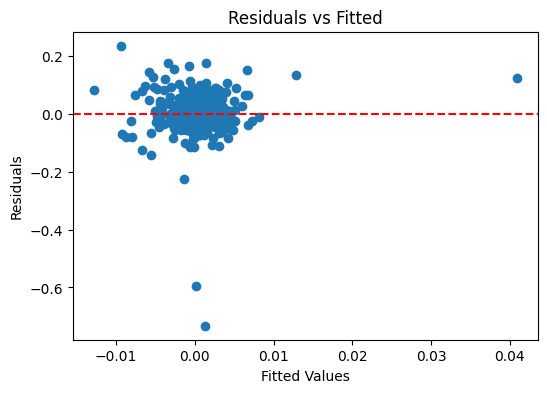

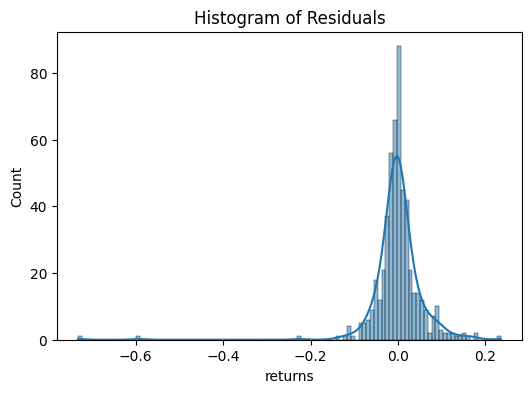

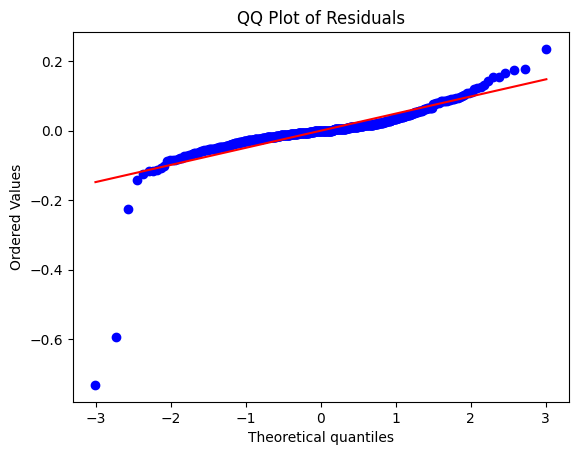

In [5]:

residuals = y_test - y_pred

# Residuals vs Fitted Plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Histogram of residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

# QQ plot for normality
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()



## Step 5: Adding a Polynomial Feature
To test improvement, we add the square of `lag1` as a new feature and refit the model.


In [6]:

data['lag1_sq'] = data['lag1'] ** 2
X2 = data[['lag1', 'lag2', 'lag1_sq']]
y2 = data['returns']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, shuffle=False)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_poly = r2_score(y2_test, y2_pred)
rmse_poly = np.sqrt(mean_squared_error(y2_test, y2_pred))

r2_poly, rmse_poly


(0.005280187021241667, 0.060524083947791255)

## **Conclusion**

In this mini-project, I explored whether simple lag-based linear regression could predict future returns of the EPIX stock. The baseline model with `lag1` and `lag2` features showed:

- **R²:** ~0.0054 (almost zero predictive power)  
- **RMSE:** ~0.0605  

Even after adding a polynomial feature (`lag1²`), the results barely changed:
- **R²:** ~0.0053  
- **RMSE:** ~0.0605  

### **Residual Insights**
- Residuals are centered around zero → no obvious bias.  
- The residual spread appears random → suggests poor predictive power.  
- QQ plots are approximately normal → indicates noise dominates the prediction.

---

### **Why This Makes Sense**
Financial returns often behave like a random walk, meaning past short-term returns don’t reliably predict future returns. This aligns with the Efficient Market Hypothesis (EMH), which suggests that any simple, exploitable patterns are quickly arbitraged away.

---

### **Key Takeaways**
- **Lagged returns alone are not enough** to build a useful model.  
- The workflow—data preparation, regression modeling, and diagnostics—was valuable for understanding **time series modeling basics**.  
- For better results, future models could explore:  
  - **Richer features** like technical indicators, volatility measures, or macroeconomic factors.  
  - **Non-linear algorithms** such as Random Forests, Gradient Boosting, or LSTMs.  